# Recitation: Unsupervised Learning
### Topics: K-Means and Hierarchical Clustering

In this recitation, we will explore core unsupervised learning techniques:
- **K-Means Clustering**: for grouping similar data points into `k` clusters
- **Hierarchical Clustering**: for building a hierarchy of clusters using a dendrogram

---

## What is Unsupervised Learning?

In unsupervised learning, we are given data **without labels**.
The goal is to uncover **patterns, structure, or relationships** within the data.

---

## Supervised vs Unsupervised Learning

| Supervised Learning         | Unsupervised Learning         |
|----------------------------|-------------------------------|
| Has labeled data            | No labels                     |
| Predict specific target     | Find patterns or structure     |
| Examples: regression, classification | Examples: clustering, dimensionality reduction |

---

## Real-World Applications

- **Customer segmentation**: group customers by behavior
- **Anomaly detection**: identify outliers in network traffic or manufacturing
- **Topic modeling**: group articles/documents by topic
- **Data compression**: reduce dimensionality for visualization or storage

---

We'll start by loading the dataset and preparing it for clustering.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

# Load dataset
data = load_iris()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [2]:
X.shape

(150, 4)

For visualization throughout this recitation, we'll use two of the original features:
**petal length** and **petal width** (indices 2 and 3). These two features alone separate the
Iris classes very well, so they are convenient for plotting cluster results in 2D.


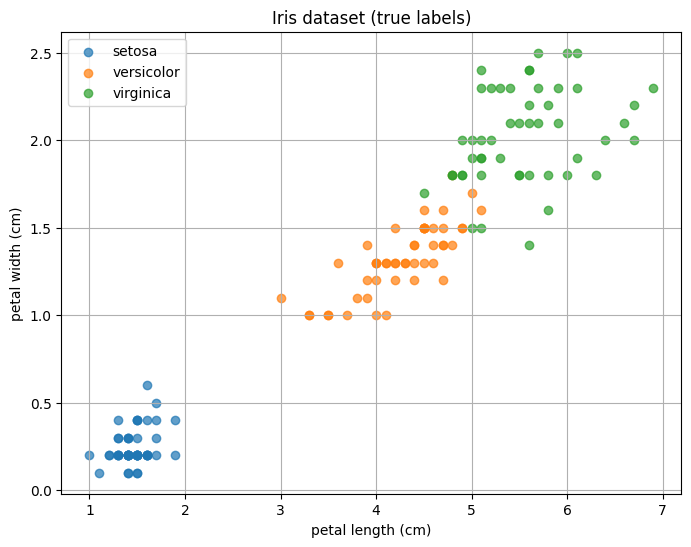

In [3]:
# Pick two features for 2D visualization
f1, f2 = 2, 3  # petal length, petal width
xlabel, ylabel = feature_names[f1], feature_names[f2]

plt.figure(figsize=(8, 6))
for i, target in enumerate(np.unique(y)):
    plt.scatter(X[y == target, f1], X[y == target, f2], label=target_names[i], alpha=0.7)
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title("Iris dataset (true labels)")
plt.legend()
plt.grid(True)
plt.show()


## Section 2: K-Means Clustering

**K-Means** is a clustering algorithm that partitions the data into **k clusters** by:

1. Initializing `k` cluster centroids
2. Assigning each point to the nearest centroid
3. Updating the centroids based on the new clusters
4. Repeating until convergence

---

### Key Parameters:
- `n_clusters`: the number of clusters (k)
- `init`: method for initializing centroids (`k-means++` is default)
- `random_state`: for reproducibility

---

### How to Choose `k`?

Two popular methods:

1. **Elbow Method**: Look for a "bend" in the plot of inertia (within-cluster sum of squares)
2. **Silhouette Score**: Measures how similar a point is to its own cluster compared to other clusters


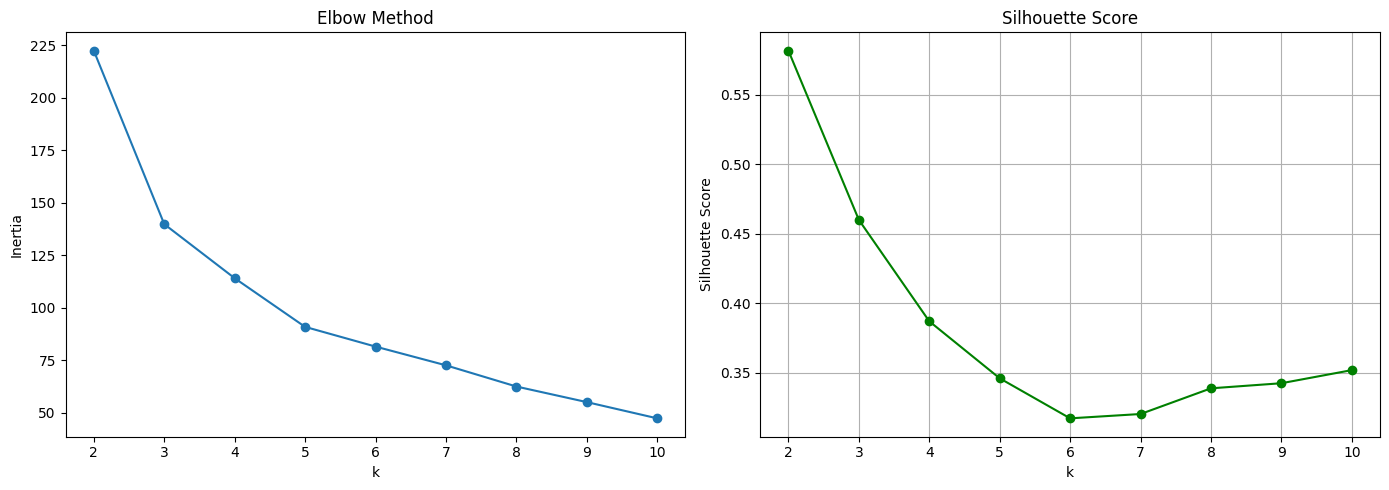

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Plot Elbow Method
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("Inertia")

# Plot Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(k_values, silhouettes, marker='o', color='green')
plt.title("Silhouette Score")
plt.xlabel("k")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.grid(True)
plt.show()


Choose the `k` where:
- The **Elbow** plot bends (flattening of inertia curve)
- The **Silhouette Score** is highest (ideally > 0.5)

Let's cluster the data using the best value of `k` and visualize the result using two of the original features.


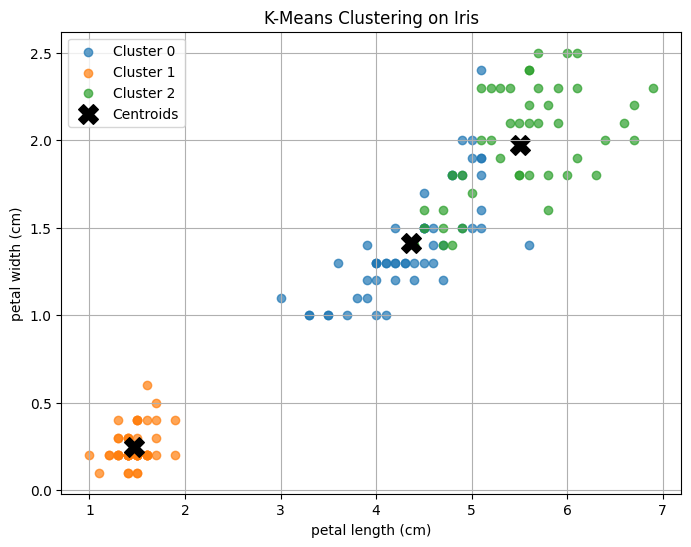

In [5]:
# Fit KMeans with best k (let's say k=3 for Iris dataset)
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Centroids are in the standardized space — invert the scaler to plot them
# in the original feature space alongside the raw data.
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))
for cluster in range(best_k):
    plt.scatter(X[cluster_labels == cluster, f1],
                X[cluster_labels == cluster, f2],
                label=f"Cluster {cluster}", alpha=0.7)

plt.scatter(centroids_orig[:, f1], centroids_orig[:, f2],
            s=200, marker='X', label='Centroids', c='black')

plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title("K-Means Clustering on Iris")
plt.legend()
plt.grid(True)
plt.show()


We successfully clustered the data using K-Means.

In the next section, we'll explore **Hierarchical Clustering**, which builds a tree of clusters instead of assigning them all at once.


## Section 3: Hierarchical Clustering

**Hierarchical Clustering** builds a hierarchy of clusters.

The most common approach is **Agglomerative Clustering**:
- Start with each point in its own cluster
- Iteratively merge the two closest clusters
- Continue until all points are in a single cluster

---

### Linkage Criteria:
- `single`: merge based on the closest pair of points
- `complete`: merge based on the farthest pair
- `average`: merge based on average distance
- `ward`: minimizes variance (default)

We can visualize the hierarchy using a **dendrogram** — a tree diagram showing merge steps.


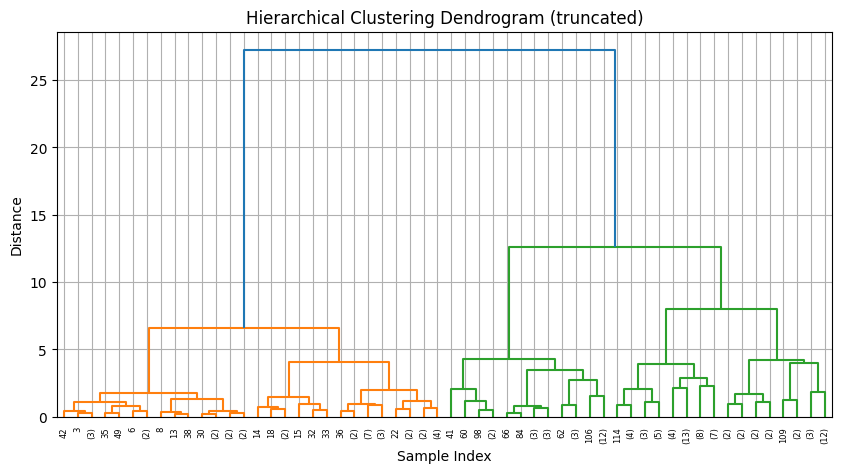

In [6]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Compute linkage matrix
linked = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram (truncated)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.grid(True)
plt.show()


We can cut the dendrogram at a chosen height to decide how many clusters to form.

Let's use `AgglomerativeClustering` to assign cluster labels.


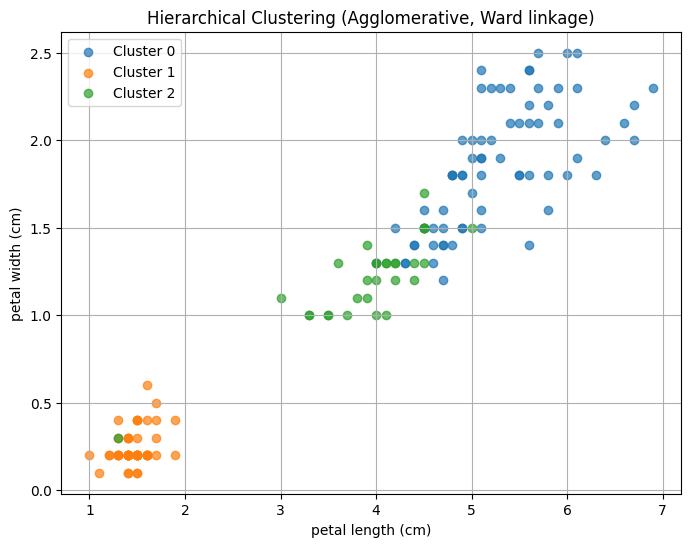

In [7]:
from sklearn.cluster import AgglomerativeClustering

# Set number of clusters
n_clusters = 3

agg_clust = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
agg_labels = agg_clust.fit_predict(X_scaled)

# Visualize using the same two original features
plt.figure(figsize=(8, 6))
for cluster in range(n_clusters):
    plt.scatter(X[agg_labels == cluster, f1],
                X[agg_labels == cluster, f2],
                label=f"Cluster {cluster}", alpha=0.7)

plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title("Hierarchical Clustering (Agglomerative, Ward linkage)")
plt.legend()
plt.grid(True)
plt.show()


Unlike K-Means, hierarchical clustering doesn't require us to initialize centroids.
It also gives us a **dendrogram** that shows how clusters form at different levels of granularity.


### Divisive Clustering (Top-Down)

In **divisive clustering**, we start with all data points in one large cluster and recursively **split** them into smaller clusters.

This is the opposite of agglomerative clustering, which starts with individual points and merges them.

Divisive clustering is not directly implemented in `scikit-learn`, but we can simulate a simple version using recursive **KMeans**.


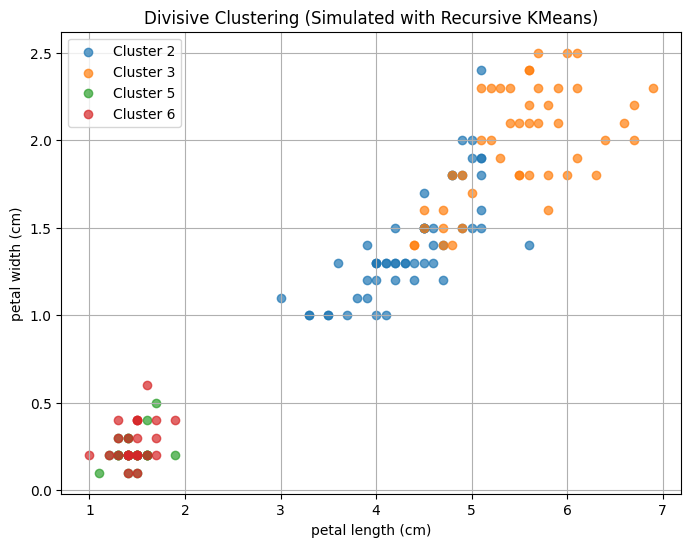

In [8]:
# Run recursive KMeans on the standardized data, visualize on two original features
n = len(X_scaled)
cluster_labels_div = np.zeros(n, dtype=int)

next_label = 1

def divisive_kmeans(X_in, indices, depth=0, max_depth=2):
    global next_label
    if depth == max_depth or len(indices) <= 2:
        return

    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    split_labels = kmeans.fit_predict(X_in[indices])

    for split_val in [0, 1]:
        sub_indices = indices[split_labels == split_val]
        cluster_labels_div[sub_indices] = next_label
        next_label += 1
        divisive_kmeans(X_in, sub_indices, depth + 1, max_depth)

divisive_kmeans(X_scaled, np.arange(n))

plt.figure(figsize=(8, 6))
for label in np.unique(cluster_labels_div):
    plt.scatter(X[cluster_labels_div == label, f1],
                X[cluster_labels_div == label, f2],
                label=f"Cluster {label}", alpha=0.7)

plt.title("Divisive Clustering (Simulated with Recursive KMeans)")
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.legend()
plt.grid(True)
plt.show()


This is a simple approximation of **divisive clustering**, using recursive KMeans splits to divide clusters top-down.

While not as precise or formal as real divisive algorithms like **DIANA**, it demonstrates the **concept** for educational purposes.

In practice, agglomerative clustering is more common and well-supported in Python.


## Section 4: Wrap-Up Summary

In this recitation, we covered two core unsupervised clustering techniques:

---

### Comparison of Methods

| Method                      | Task        | Key Idea                                  | Strengths                     | Limitations                                  |
|-----------------------------|-------------|--------------------------------------------|-------------------------------|----------------------------------------------|
| **K-Means Clustering**      | Clustering  | Partition into `k` groups by distance      | Simple, scalable              | Assumes spherical clusters, must choose `k`  |
| **Hierarchical Clustering** | Clustering  | Build tree of clusters from bottom up      | Dendrogram, no need for `k`   | Computationally expensive on large data      |

---

### Key Takeaways

- **K-Means** is useful when you know (or can estimate) the number of clusters.
- **Hierarchical Clustering** gives a more flexible structure but is slower and more sensitive to noise.
- Always **standardize** your features before applying distance-based clustering (like K-Means and Agglomerative Clustering).
